In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["AUTOGRAPH_VERBOSITY"] = "0"
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
import unicodedata
from keras import layers
from keras import ops

from keras.layers import Layer, Embedding, Input, Dense, GlobalAveragePooling1D, Dropout, MultiHeadAttention, LayerNormalization 
from keras.models import Model

import numpy as np
import random

import tensorflow as tf

# Introduction  

The purpose of this project is to learn about transformer architecture, specifically its encoder and decoder components, their function and purpose as well as concepts such as cross-attention.  
In addition this project is an exercise in chaining different transformer models together by attempting to translate transcribed audio by a audio-to-text transformer.  
This project is done with the guidance of [Deep Learning With Python](https://deeplearningwithpython.io/) By François Chollet and Matthew Watson

# Data Understanding  

The intiial plan for a dataset was the simply use a substantial text collection (such as an ebook) from both languages. However upon learning more about transformer structure this proved to be a unviable approach.  
For the transformer to properly work the dataset instead needs to be in word pairs, where first of the pair is in the source language i.e. the language to be translated and the other one in the target language i.e. the language to translate to.  
Luckily there exists multiple choices for viable datasets even in this format such as transcripts written down in multiple languages or volunteer collection of translated sentences.  
The latter of the options is the chosen approach for this project.  
Dataset sourced from https://tatoeba.org/en/downloads


## Loading Data  

For the chosen method of translation to work, the target language pair of the language pairs needs to be modified to include signifiers for their starting and ending positions.  
This is because during the translation the model keeps predicting the highest probability tokenized word, until the predicted token is the [end] token.

In [2]:
text_file = "/home/valvoja/projects/2026-Spring-Neural-Network-Project/dataset-local/Sentence pairs in Finnish-English - 2026-04-30.tsv"

text_pairs = []
with open(text_file, encoding='utf-8') as f:
    for line in f:
        val1, finnish, val2, english = line.strip().split("\t")
        english = "[start] " + english + " [end]"
        text_pairs.append((finnish, english))
        
print(text_pairs[:4])

[('Lue mittarin lukema.', '[start] Read the meter. [end]'), ('Imuroin pölyt lattialta pölynimurilla.', '[start] I sucked up the dust on the floor with a vacuum cleaner. [end]'), ('Kuulin sen suoraan naapuriltani.', '[start] I heard about it at first hand from my neighbor. [end]'), ('Heinäkuun kymmenentenä avaamme Sapporoon sivuliikkeen.', '[start] On July 10, we will open our Sapporo branch. [end]')]


## Normalising Text  


In [3]:
def normalize(text):
    """Lowercase and normalize unicode (e.g. accents)."""
    text = text.lower().strip()
    text = unicodedata.normalize("NFC", text)
    return text

text_pairs = [(normalize(fi), normalize(en)) for fi, en in text_pairs]

In [4]:
print("Number of sentence pairs:", len(text_pairs))
print("Example pair:")
print("Finnish:", text_pairs[0][0])
print("English:", text_pairs[0][1])

Number of sentence pairs: 105178
Example pair:
Finnish: lue mittarin lukema.
English: [start] read the meter. [end]


## Preparing Data

### Train, Test and Validation Splits

In [5]:
val_samples = int(0.15 * len(text_pairs))
train_samples = len(text_pairs) - 2 * val_samples
train_pairs = text_pairs[:train_samples]
val_pairs = text_pairs[train_samples : train_samples + val_samples]
test_pairs = text_pairs[train_samples + val_samples :]

In [6]:
batch_size = 32
vocab_size = 10000
sequence_length = 20

## Keras Layers Method Tokenizing

In [7]:
import re
import string

# To keep [start] and [end] from turning into "start" and "end"
strip_chars = string.punctuation
strip_chars = strip_chars.replace("[", "")
strip_chars = strip_chars.replace("]", "")

def custom_standardization(input_string):
    lowercase = tf.strings.lower(input_string)
    return tf.strings.regex_replace(
        lowercase,
        f"[{re.escape(strip_chars)}]",
        ""
    )

finnish_tokenizer = layers.TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length,
    standardize=custom_standardization,
)
english_tokenizer = layers.TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length + 1,
    standardize=custom_standardization,
)

train_finnish_texts = [pair[0] for pair in train_pairs]
train_english_texts = [pair[1] for pair in train_pairs]
finnish_tokenizer.adapt(train_finnish_texts)
english_tokenizer.adapt(train_english_texts)

I0000 00:00:1778167161.611636   14839 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5562 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:01:00.0, compute capability: 8.6


In [8]:
print(train_pairs[0])

('lue mittarin lukema.', '[start] read the meter. [end]')


### Remerging Tokenized Texts

In [9]:
def format_dataset(fin, eng):
    eng = english_tokenizer(eng)
    fin = finnish_tokenizer(fin)
    features = {"finnish": fin, "english": eng[:, :-1]}
    labels = eng[:, 1:]
    sample_weights = labels != 0
    return features, labels, sample_weights

def make_dataset(pairs):
    fin_texts, eng_texts = zip(*pairs)
    fin_texts = list(fin_texts)
    eng_texts = list(eng_texts)
    dataset = tf.data.Dataset.from_tensor_slices((fin_texts, eng_texts))
    dataset = dataset.batch(batch_size)
    dataset = dataset.map(format_dataset, num_parallel_calls=4)
    return dataset.shuffle(2048).cache()

train_ds = make_dataset(train_pairs)
val_ds = make_dataset(val_pairs)

## Token and Position Encoding

In [10]:
class PositionalEmbedding(keras.Layer):
    def __init__(self, sequence_length, input_dim, output_dim):
        super().__init__()
        self.token_embeddings = layers.Embedding(input_dim, output_dim)
        self.position_embeddings = layers.Embedding(sequence_length, output_dim)

    def call(self, inputs):
        # Computes incrementing positions [0, 1, 2...] for each
        # sequence in the batch
        positions = ops.cumsum(ops.ones_like(inputs), axis=-1) - 1
        embedded_tokens = self.token_embeddings(inputs)
        embedded_positions = self.position_embeddings(positions)
        return embedded_tokens + embedded_positions

In [11]:
embed_dim = 32 # dimension of word embeddings (token + pos)
dense_dim = 128
num_heads = 2
key_dim = embed_dim // num_heads
encoder_layers = 1
decoder_layers = 1

# Initial Scoping of the Transformer  

The transformer structure was initially scoped layer by layer and constructed into a functional model from those layers. This version of the transformer is also provided below with the comments stripped for easier inspection of its structure.  

In [12]:
# Layer and Positional embedding
# Either together or in sequence

source = keras.Input(shape=(None,), dtype="int64", name="finnish")
x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(source)

# Encoder block starts here

# Input for the encoder block will be the origin language sentence.
# Save original input into a variable to create a residual connection
for _ in range(encoder_layers):
    residual = x
    
    # Multihead self-attention layer with no mask (except for filling out dud words)
    attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)  
    
    # Save the outputs of the normalisation layer into another variable for another residual connection
    # the output of the attention layer is here added to the original data from the residual connection and then normalised
    x = LayerNormalization()(attention_output + residual)
    residual = x
    
    # Output of the normalisation layer is fed into a feedforward layer. (Amount of hidden layers to be adjusted)
    ff_output = Dense(dense_dim, activation="relu") (x)
    ff2_output = Dense(embed_dim)(ff_output)
    
    # Output of the feedforward layer is added to data from the residual connection and the result normalised
    x = LayerNormalization()(ff2_output + residual)
    
encoder_output = x
# This process is repeated for as many encoder blocks you want.
# Then the data is ready to be fed into the decoder block

In [13]:
# Layer and Positional embdedding
# Either together or in sequence
target = keras.Input(shape=(None,), dtype="int64", name="english")
x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(target)

# Decoder block starts here

# Input for the decoder block will be the translated language
# Save original input into a variable to create a residual connection
for _ in range(decoder_layers): 
    residual = x
    
    # Input is fed into a multihead self-attention layer with a causal mask
    attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x, use_causal_mask=True)  
    
    # Output of the attention layer is added into the data from the residual connection and then normalised
    x = LayerNormalization()(attention_output + residual)
    
    # Save the normalised data into a variable for a residual connection
    residual = x
    
    # The output of the normalisation layer is the query attribute of the layer
    # Key and Value attributes are obtained from the final output of the encoder
    attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, encoder_output, encoder_output)  
    
    # Output of this attention layer is added to the data from the residual connection and normalised
    x = LayerNormalization()(attention_output + residual)
    
    # This data is saved to a variable to create a residual connection
    residual = x
    
    # Output of the normalisation layer is fed into a feedforward layer (Amount of hidden layers to be adjusted)
    ff_output = Dense(512, activation="relu")(x)
    ff2_output = Dense(32)(ff_output)
    
    # Output of the feedforward layer is added to the data from the residual connection and normalised
    x = LayerNormalization()(ff2_output + residual)

# Output of the normalisation layer is the finished translation
#output = layers.Dropout(0.5)(x)
target_predictions = layers.Dense(vocab_size, activation="softmax")(x)
transformer = keras.Model([source, target], target_predictions)

In [14]:
"""
source = keras.Input(shape=(None,), dtype="int64", name="finnish")
x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(source)

for _ in range(encoder_layers):
    residual = x
    
    attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)  
    x = LayerNormalization()(attention_output + residual)
    residual = x
    
    ff_output = Dense(dense_dim, activation="relu") (x)
    ff2_output = Dense(embed_dim)(ff_output)
    
    x = LayerNormalization()(ff2_output + residual)
    
encoder_output = x

target = keras.Input(shape=(None,), dtype="int64", name="english")
x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(target)

for _ in range(decoder_layers): 
    residual = x
    
    attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x, use_causal_mask=True)  
    x = LayerNormalization()(attention_output + residual)
    
    residual = x
    
    attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, encoder_output, encoder_output)  
    x = LayerNormalization()(attention_output + residual)
    
    residual = x
    
    ff_output = Dense(512, activation="relu")(x)
    ff2_output = Dense(32)(ff_output)
    
    x = LayerNormalization()(ff2_output + residual)

target_predictions = layers.Dense(vocab_size, activation="softmax")(x)
transformer = keras.Model([source, target], target_predictions)
"""

'\nsource = keras.Input(shape=(None,), dtype="int64", name="finnish")\nx = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(source)\n\nfor _ in range(encoder_layers):\n    residual = x\n\n    attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)  \n    x = LayerNormalization()(attention_output + residual)\n    residual = x\n\n    ff_output = Dense(dense_dim, activation="relu") (x)\n    ff2_output = Dense(embed_dim)(ff_output)\n\n    x = LayerNormalization()(ff2_output + residual)\n\nencoder_output = x\n\ntarget = keras.Input(shape=(None,), dtype="int64", name="english")\nx = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(target)\n\nfor _ in range(decoder_layers): \n    residual = x\n\n    attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x, use_causal_mask=True)  \n    x = LayerNormalization()(attention_output + residual)\n\n    residual = x\n\n    attention_output = MultiHeadAttention(num_heads=num_heads,

## Self-Attention and Cross-Attention  

This version of the transformer still remains valuable to emphasize the difference between self-attention and cross-attention. The primary function of the transformer in translation tasks lies in the interaction between encoder and decoder.  
In the encoder block through its self-attention layer the model creates connections between the tokenised source language words. These tokens with new meaning attributed to them will be important in cross-attention.    
Similiar process is initially done in the decoder block to the tokenized target language words, with the difference of the use of a causal mask, which prevents the layer from utilising information about upcoming tokens in the current sequence.  

Because both the source language and the target language go through a self-attention layer the desired outcome is that, due to all the pre-processing done by embedding information into the tokenized word vectors, both the encoder and decoder have produced attention matrices (comprised of query, key and value) that contain information about the connection between the words.    

This leads to the key part of the transformer: Cross-Attention.  
Because for translating purposes it isn't enough that the target language retains information purely about its own language. It has to account for the source language as well.
By treating the input of query as the output of the decoder attention layer, but the key and value inputs as output from the encoder this allows the transformer to slowly adapt the target language attention matrices to account for the information from the source language as well.  


In [15]:
transformer.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ finnish             │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, None, 32)  │    320,640 │ finnish[0][0]     │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, None, 32)  │      4,224 │ positional_embed… │
│ (MultiHeadAttentio… │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, None, 32)  │          0 │ multi_head_atten… │
│                     │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ english             │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, None, 32)  │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, None, 32)  │    320,640 │ english[0][0]     │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, None, 128) │      4,224 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, None, 32)  │      4,224 │ positional_embed… │
│ (MultiHeadAttentio… │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, None, 32)  │      4,128 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, None, 32)  │          0 │ multi_head_atten… │
│                     │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, None, 32)  │          0 │ dense_1[0][0],    │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, None, 32)  │         64 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, None, 32)  │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, None, 32)  │      4,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, None, 32)  │          0 │ multi_head_atten… │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, None, 32)  │         64 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 1,025,936 (3.91 MB)

 Trainable params: 1,025,936 (3.91 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
#transformer.keras.save('initial-transformer')

# Tidying Up The Structure  

As far as mapping and figuring out the structure of a transformer goes the above model works well enough.  
However restructuring the encoder and decoder into a class is not only the standard procedure, but it looks nicer, is more legible and makes their stacking more clear and concise.  

To accomplish this we simply define each of the necessary layers of the neural network as attributes of the class and then determine the structure of the respective blocks, as well as the values used by those layers in a seperate call function.

In [17]:
class EncoderBlock(keras.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, dropout=0.1):
        super().__init__()
        key_dim = embed_dim // num_heads
        self.self_attention = layers.MultiHeadAttention(num_heads, key_dim)
        self.attention_norm = layers.LayerNormalization()
        self.ff1 = layers.Dense(dense_dim, activation='relu')
        self.ff2 = layers.Dense(embed_dim)
        self.ff_norm = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)


    def call(self, source, source_mask, training=False):
        residual = x = source
        mask = source_mask[:, None, :]
        
        x = self.self_attention(query=x, key=x, value=x, attention_mask=mask)
        x = self.dropout1(x, training=training)
        x = x + residual
        x = self.attention_norm(x)
        
        residual = x
        x = self.ff1(x)
        x = self.ff2(x)
        x = self.dropout2(x, training=training)
        x = x + residual
        x = self.ff_norm(x)
        return x
        

In [18]:
class DecoderBlock(keras.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, dropout=0.1):
        super().__init__()
        key_dim = embed_dim // num_heads
        self.self_attention_masked = layers.MultiHeadAttention(num_heads, key_dim)
        self.attention_norm = layers.LayerNormalization()
        self.cross_attention = layers.MultiHeadAttention(num_heads, key_dim)
        self.cross_attention_norm = layers.LayerNormalization()
        self.ff1 = layers.Dense(dense_dim, activation='relu')
        self.ff2 = layers.Dense(embed_dim)
        self.ff_norm = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)
        self.dropout3 = layers.Dropout(dropout)
        

    def call(self, target, source, source_mask, training=False):
        residual = x = target
        x = self.self_attention_masked(query=x, key=x, value=x, use_causal_mask=True)
        x = self.dropout1(x, training=training)
        x = x + residual
        x = self.attention_norm(x)

        residual = x
        mask = source_mask[:, None, :]
        x = self.cross_attention(query=x, key=source, value=source, attention_mask=mask)
        x = self.dropout2(x, training=training)
        x = x + residual
        x = self.cross_attention_norm(x)

        residual = x
        x = self.ff1(x)
        x = self.ff2(x)
        x = self.dropout3(x, training=training)
        x = x + residual
        x = self.ff_norm(x)
        return x
        

# Stacking Blocks  

The above encoder and decoder blocks would serve the transformer just fine, however their original purpose was designed to be stackable in the transformer.  
While it would be practical to simply call each block sequentially when defining a model, it is standard for to create proper encoder and decoder classes wherein the encoder and decoder block logic is looped.  
This is as simple as creating encoder and decoder classes with attributes containing a list of the necessary amount of encoder and decoder blocks.  

In [19]:
class Encoder(keras.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, num_layers, dropout=0.1):
        super().__init__()
        self.encoder_stack = [EncoderBlock(embed_dim, dense_dim, num_heads, dropout) for _ in range(num_layers)]

    def call(self, source, source_mask, training=False):
        x = source
        for encoder in self.encoder_stack:
            x = encoder(x, source_mask, training=training)
        return x

In [20]:
class Decoder(keras.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, num_layers, dropout=0.1):
        super().__init__()
        self.decoder_stack = [DecoderBlock(embed_dim, dense_dim, num_heads, dropout) for _ in range(num_layers)]

    def call(self, target, source, source_mask, training=False):
        x = target
        for decoder in self.decoder_stack:
            x = decoder(x, source, source_mask, training=training)
        return x

# Building the Transformer

In [21]:
source = keras.Input(shape=(None,), dtype="int64", name="finnish")
x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(source)
encoder_output = Encoder(embed_dim, dense_dim, num_heads, encoder_layers)(source=x, source_mask=source != 0)

target = keras.Input(shape=(None,), dtype="int64", name="english")
x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(target)
x = Decoder(embed_dim, dense_dim, num_heads, decoder_layers)(target=x, source=encoder_output, source_mask=source != 0)

x = layers.Dropout(0.5)(x)
target_predictions = layers.Dense(vocab_size, activation="softmax")(x)
transformer2 = keras.Model([source, target], target_predictions)

In [22]:
transformer2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ finnish             │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, None, 32)  │    320,640 │ finnish[0][0]     │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ finnish[0][0]     │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ english             │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder (Encoder)   │ (None, None, 32)  │     12,704 │ positional_embed… │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, None)      │          0 │ finnish[0][0]     │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, None, 32)  │    320,640 │ english[0][0]     │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder (Decoder)   │ (None, None, 32)  │     16,992 │ encoder[0][0],    │
│                     │                   │            │ not_equal_1[0][0… │
│                     │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, None, 32)  │          0 │ decoder[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, None,      │    330,000 │ dropout_11[0][0]  │
│                     │ 10000)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,000,976 (3.82 MB)

 Trainable params: 1,000,976 (3.82 MB)

 Non-trainable params: 0 (0.00 B)

# Training The Model

In [23]:
transformer2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    weighted_metrics=["accuracy"],
)
history = transformer2.fit(train_ds, epochs=15, validation_data=val_ds)

Epoch 1/15
  33/2301 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.0685 - loss: 3.4492

I0000 00:00:1778167190.449608   14942 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2301/2301 ━━━━━━━━━━━━━━━━━━━━ 57s 14ms/step - accuracy: 0.2311 - loss: 1.9312 - val_accuracy: 0.3175 - val_loss: 1.4793
Epoch 2/15
2301/2301 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.3260 - loss: 1.5739 - val_accuracy: 0.3775 - val_loss: 1.3289
Epoch 3/15
2301/2301 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.3741 - loss: 1.4184 - val_accuracy: 0.4176 - val_loss: 1.2396
Epoch 4/15
2301/2301 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.4062 - loss: 1.3203 - val_accuracy: 0.4424 - val_loss: 1.1842
Epoch 5/15
2301/2301 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.4310 - loss: 1.2473 - val_accuracy: 0.4620 - val_loss: 1.1544
Epoch 6/15
2301/2301 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.4478 - loss: 1.1956 - val_accuracy: 0.4746 - val_loss: 1.1304
Epoch 7/15
2301/2301 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.4629 - loss: 1.1523 - val_accuracy: 0.4832 - val_loss: 1.1128
Epoch 8/15
2301/2301 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.4736 - loss: 1.1204 - val_

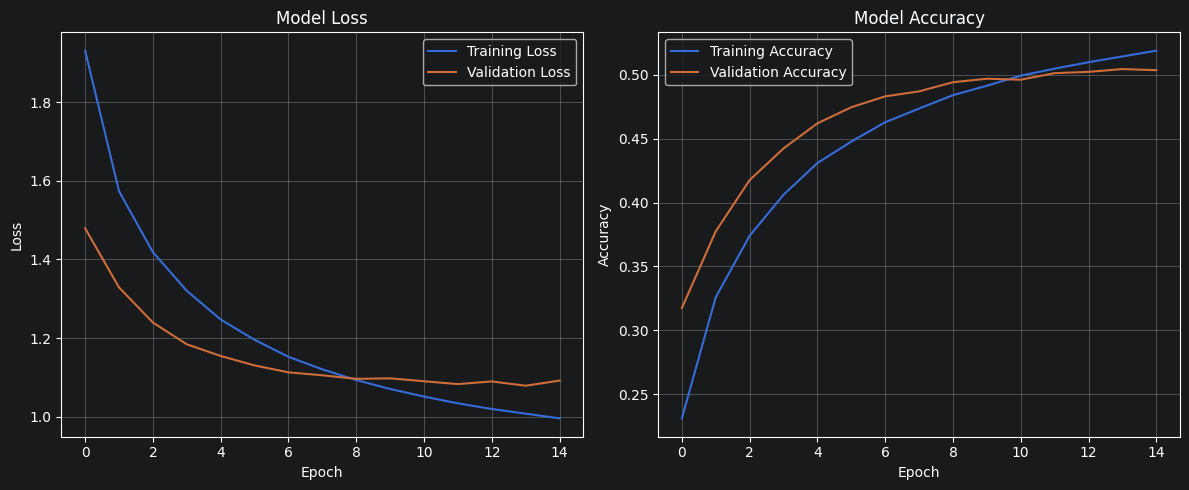

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

In [25]:
eng_vocab = english_tokenizer.get_vocabulary()
eng_index_lookup = dict(zip(range(len(eng_vocab)), eng_vocab))

def clean_translation(text):
    return text.replace("[start]", "").replace("[end]", "").strip()

def generate_translation(input_sentence):
    tokenized_input_sentence = finnish_tokenizer([input_sentence])
    decoded_sentence = "[start]"

    for i in range(sequence_length):
        tokenized_target_sentence = english_tokenizer([decoded_sentence])
        tokenized_target_sentence = tokenized_target_sentence[:, :-1]

        inputs = [tokenized_input_sentence, tokenized_target_sentence]
        next_token_predictions = transformer2.predict(inputs, verbose=0)

        sampled_token_index = np.argmax(next_token_predictions[0, i, :])
        sampled_token = eng_index_lookup[sampled_token_index]

        decoded_sentence += " " + sampled_token

        if sampled_token == "[end]":
            break

    return clean_translation(decoded_sentence)


In [26]:
for finnish, english in random.sample(test_pairs, k=min(5, len(test_pairs))):
    print("-")
    print("Finnish input:     ", finnish)
    print("Reference English: ", clean_translation(english))
    print("Model translation:", generate_translation(finnish))

-
Finnish input:      katsoitko olympialaisten päättäjäisseremoniaa?
Reference English:  did you watch the olympics closing ceremony?
Model translation: did you look [UNK]
-
Finnish input:      katson uutiset joka aamu.
Reference English:  i watch the news every morning.
Model translation: i watch the news every morning
-
Finnish input:      mitä sun autossa on?
Reference English:  what's in your car?
Model translation: what the car is your car
-
Finnish input:      tämä maaperä on hyvin humuspitoinen.
Reference English:  this soil is rich in humus.
Model translation: this [UNK] is very [UNK]
-
Finnish input:      suoraan sanottuna tulimme ottamaan sinut kiinni.
Reference English:  to be honest, we came to capture you.
Model translation: [UNK] [UNK] you get to get you


In [27]:
# Test with a custom sentence
print(generate_translation("tämä on uusi lause"))

this is a new sentence


## Using OpenAI Whisper For Transcription

Next we will be using a pre-trained OpenAI Whisper model to transcribe a Finnish audio clip into Finnish text. The transcription will then be used as input for the custom Finnish to English translator we have built effectively creating a pipeline that can translate Finnish audio into English text.

In [28]:
from pathlib import Path
import torch
import whisper
from IPython.display import Audio, display
# pip install openai-whisper

AUDIO_ROOT = Path("/home/valvoja/projects/2026-Spring-Neural-Network-Project/assignment-3/hand-picked-dataset")

audio_clips = [
    AUDIO_ROOT / "file_1.mp3",
    AUDIO_ROOT / "file_2.mp3",
    AUDIO_ROOT / "file_3.mp3",
    AUDIO_ROOT / "file_4.mp3",
    AUDIO_ROOT / "file_5.mp3",
]

whisper_model_size = "medium"
#device = "cuda" if torch.cuda.is_available() else "cpu"
device = "cpu"

whisper_model = whisper.load_model(
    whisper_model_size,
    device=device
)

print(f"Loaded Whisper model: {whisper_model_size} on device: {device}")

def transcribe_finnish_audio(audio_path):
    """Transcribe a Finnish audio file into Finnish text with pretrained Whisper."""
    audio_path = Path(audio_path)

    result = whisper_model.transcribe(
        str(audio_path),
        language="fi",
        task="transcribe",
        fp16=(device == "cuda"),
    )

    transcription = result["text"].strip()
    return transcription

Loaded Whisper model: medium on device: cpu


### Generating the Transcriptions using the Whisper Model

Now we will be running the transcription function for 3 of the audio clips and printing the results to verify that the transcriptions are generated correctly.

In [29]:
whisper_results = []

for audio_path in audio_clips[:3]:
    print("=" * 80)
    print("Audio file:", audio_path)
    display(Audio(filename=str(audio_path)))

    finnish_transcription = transcribe_finnish_audio(audio_path)
    whisper_results.append(
        {
            "audio_path": audio_path,
            "finnish_transcription": finnish_transcription,
        }
    )

    print("Whisper Finnish transcription:")
    print(finnish_transcription)

Audio file: /home/valvoja/projects/2026-Spring-Neural-Network-Project/assignment-3/hand-picked-dataset/file_1.mp3


/home/valvoja/miniconda3/envs/keras/lib/python3.11/site-packages/whisper/transcribe.py:130: UserWarning: Performing inference on CPU when CUDA is available
  warnings.warn("Performing inference on CPU when CUDA is available")


Whisper Finnish transcription:
Nykyiset rajoitustoimittavat luonteelta on pääasiassa hyvin yleisiä ja laajoja fyysisten kontaktien vähentämisen tähtävien rajoituksia.
Audio file: /home/valvoja/projects/2026-Spring-Neural-Network-Project/assignment-3/hand-picked-dataset/file_2.mp3


/home/valvoja/miniconda3/envs/keras/lib/python3.11/site-packages/whisper/transcribe.py:130: UserWarning: Performing inference on CPU when CUDA is available
  warnings.warn("Performing inference on CPU when CUDA is available")


Whisper Finnish transcription:
Suositusta on perusteltua jatkaa, jotta altistusta lehikontakteille ja tartuntariskille voidaan vähentää.
Audio file: /home/valvoja/projects/2026-Spring-Neural-Network-Project/assignment-3/hand-picked-dataset/file_3.mp3


/home/valvoja/miniconda3/envs/keras/lib/python3.11/site-packages/whisper/transcribe.py:130: UserWarning: Performing inference on CPU when CUDA is available
  warnings.warn("Performing inference on CPU when CUDA is available")


Whisper Finnish transcription:
Siikamäen rautatieasema on Suomen rataverkolla Pieksemäen kaupungissa etelä-Savossa rataosalla Pieksemäki-Joensuu sijaitseva rautatieliikennepaikka.


### Translating Whisper Transcriptions With The Custom Model

Now the transcriptions generated by the Whisper model will be passed into the custom Transformer translator model to generate English translations from the Finnish Audio clips.

In [30]:
whisper_translation_results = []

for item in whisper_results:
    audio_path = item["audio_path"]
    finnish_transcription = item["finnish_transcription"]

    english_translation = generate_translation(finnish_transcription)

    result = {
        "audio_path": audio_path,
        "finnish_transcription": finnish_transcription,
        "english_translation": english_translation,
    }
    whisper_translation_results.append(result)

    print()
    print("Audio file:                ", audio_path)
    print("Whisper transcription:     ", finnish_transcription)
    print("Custom English translation:", english_translation)


Audio file:                 /home/valvoja/projects/2026-Spring-Neural-Network-Project/assignment-3/hand-picked-dataset/file_1.mp3
Whisper transcription:      Nykyiset rajoitustoimittavat luonteelta on pääasiassa hyvin yleisiä ja laajoja fyysisten kontaktien vähentämisen tähtävien rajoituksia.
Custom English translation: the [UNK] [UNK] [UNK] [UNK] is very well in the [UNK] [UNK] [UNK] [UNK]

Audio file:                 /home/valvoja/projects/2026-Spring-Neural-Network-Project/assignment-3/hand-picked-dataset/file_2.mp3
Whisper transcription:      Suositusta on perusteltua jatkaa, jotta altistusta lehikontakteille ja tartuntariskille voidaan vähentää.
Custom English translation: the [UNK] is [UNK] in the [UNK]

Audio file:                 /home/valvoja/projects/2026-Spring-Neural-Network-Project/assignment-3/hand-picked-dataset/file_3.mp3
Whisper transcription:      Siikamäen rautatieasema on Suomen rataverkolla Pieksemäen kaupungissa etelä-Savossa rataosalla Pieksemäki-Joensuu sijaits

## TTS for English text to English audio

Next we will be using a pre-trained text-to-speech model to convert the English translations generated by our custom transformer model into English audio files.

The model used here is a pretrained English text-to-speech model by Facebook from Hugging Face.

In [31]:
import soundfile as sf
# pip install soundfile
from transformers import AutoTokenizer, VitsModel

tts_model_name = "facebook/mms-tts-eng"

tts_device = "cpu"

tts_tokenizer = AutoTokenizer.from_pretrained(tts_model_name)
tts_model = VitsModel.from_pretrained(tts_model_name).to(tts_device)
tts_model.eval()

tts_output_dir = Path("/home/valvoja/projects/2026-Spring-Neural-Network-Project/project/tts-output")
tts_output_dir.mkdir(parents=True, exist_ok=True)

def text_to_speech(text, output_file):
    text = str(text).strip()

    output_path = tts_output_dir / output_file

    inputs = tts_tokenizer(text, return_tensors="pt")
    inputs = {key: value.to(tts_device) for key, value in inputs.items()}

    with torch.no_grad():
        waveform = tts_model(**inputs).waveform

    waveform = waveform.squeeze().cpu().numpy()
    sampling_rate = int(tts_model.config.sampling_rate)

    sf.write(str(output_path), waveform, sampling_rate)

    return output_path


Loading weights:   0%|          | 0/762 [00:00<?, ?it/s]

Running a test of the text-to-speech model with a sample English text to verify that it works correctly and generates an audio file that can be played back in the notebook.

In [32]:
tts_test_text = "This is a test of the English text to speech model."
tts_test_path = text_to_speech(
    tts_test_text,
    "tts_test.wav",
)

print("TTS input text:")
print(tts_test_text)
print("\nGenerated audio file:")
print(tts_test_path)

display(Audio(filename=str(tts_test_path)))

TTS input text:
This is a test of the English text to speech model.

Generated audio file:
/home/valvoja/projects/2026-Spring-Neural-Network-Project/project/tts-output/tts_test.wav


## Full Audio to Audio Translation Pipeline

The final step is to combine all the steps into a single function that takes a Finnish audio file as input and produces an English audio file as output.

`Finnish audio -> Finnish text (Whisper) -> English text (Custom Transformer) -> English audio (TTS)`

In [33]:
def audio_to_audio_translate(audio_path):
    audio_path = Path(audio_path)

    finnish_transcription = transcribe_finnish_audio(audio_path)
    english_translation = generate_translation(finnish_transcription)

    english_audio_path = text_to_speech(
        english_translation,
        tts_output_dir / f"{audio_path.stem}.wav",
    )

    return {
        "input_audio_path": audio_path,
        "finnish_transcription": finnish_transcription,
        "english_translation": english_translation,
        "output_audio_path": english_audio_path,
    }


Running the full audio to audio translation pipeline for all the audio clips.

In [34]:
for audio_clip in audio_clips:
    result = audio_to_audio_translate(audio_clip)

    print()
    print("Input Finnish audio:")
    print(result["input_audio_path"])
    display(Audio(filename=str(result["input_audio_path"])))

    print("Whisper Finnish transcription:")
    print(result["finnish_transcription"])

    print("Custom English translation:")
    print(result["english_translation"])

    print("Generated English audio:")
    print(result["output_audio_path"])
    display(Audio(filename=str(result["output_audio_path"])))


/home/valvoja/miniconda3/envs/keras/lib/python3.11/site-packages/whisper/transcribe.py:130: UserWarning: Performing inference on CPU when CUDA is available
  warnings.warn("Performing inference on CPU when CUDA is available")



Input Finnish audio:
/home/valvoja/projects/2026-Spring-Neural-Network-Project/assignment-3/hand-picked-dataset/file_1.mp3


Whisper Finnish transcription:
Nykyiset rajoitustoimittavat luonteelta on pääasiassa hyvin yleisiä ja laajoja fyysisten kontaktien vähentämisen tähtävien rajoituksia.
Custom English translation:
the [UNK] [UNK] [UNK] [UNK] is very well in the [UNK] [UNK] [UNK] [UNK]
Generated English audio:
/home/valvoja/projects/2026-Spring-Neural-Network-Project/project/tts-output/file_1.wav


/home/valvoja/miniconda3/envs/keras/lib/python3.11/site-packages/whisper/transcribe.py:130: UserWarning: Performing inference on CPU when CUDA is available
  warnings.warn("Performing inference on CPU when CUDA is available")



Input Finnish audio:
/home/valvoja/projects/2026-Spring-Neural-Network-Project/assignment-3/hand-picked-dataset/file_2.mp3


...


Input Finnish audio:
/home/valvoja/projects/2026-Spring-Neural-Network-Project/assignment-3/hand-picked-dataset/file_4.mp3


Whisper Finnish transcription:
Nämä ovat osoittautuneet toivolliseksi keinoiksi rohkaista opiskelijoita ja opettajia arjaannut tämän kielitaitoaan.
Custom English translation:
these are [UNK] a [UNK] [UNK] [UNK] and [UNK] [UNK]
Generated English audio:
/home/valvoja/projects/2026-Spring-Neural-Network-Project/project/tts-output/file_4.wav


/home/valvoja/miniconda3/envs/keras/lib/python3.11/site-packages/whisper/transcribe.py:130: UserWarning: Performing inference on CPU when CUDA is available
  warnings.warn("Performing inference on CPU when CUDA is available")



Input Finnish audio:
/home/valvoja/projects/2026-Spring-Neural-Network-Project/assignment-3/hand-picked-dataset/file_5.mp3


Whisper Finnish transcription:
En nimittäin ole tavannut ainuttakaan työnantajien edustajaa, joka kannattaisi teille tarkistustua.
Custom English translation:
i dont have a [UNK] [UNK] [UNK] [UNK]
Generated English audio:
/home/valvoja/projects/2026-Spring-Neural-Network-Project/project/tts-output/file_5.wav


## AI Transparency  

AI generated code from Claude and ChatGPT were used in this project solely for comparison as a means of determining progress.  
AI tools such as ChatGPT were used in troubleshooting issues and debugging.